In [43]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data", exist_ok=True)

In [44]:
portfolio = pd.read_csv("data/portfolio_returns_log.csv", index_col=0, parse_dates=True)
asset_returns = pd.read_csv("data/returns_log.csv", index_col="Date", parse_dates=True)
prices = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
weights = pd.read_csv("data/weights.csv", index_col=0)

#print(portfolio)

#print(weight)

In [45]:
CONFIDENCE_1 = 0.95
CONFIDENCE_2 = 0.99
TRADING_DAYS = 252

#START = "2025-06-01"
END = "2025-12-31"


START = "2020-03-01"   # start date
END   = "2020-05-01" 

EQUITY_SHOCK = -0.30
RATE_SHOCK_BPS = 200
BOND_SHOCK = -0.20
FX_SHOCK = -0.08
GOLD_SHOCK = -0.12


In [46]:
# ---  Second scenario : Market shock ---
market_window = portfolio.loc[START:END].dropna()
print(f"Window: {START} -> {END} ({len(market_window)} days)")

if market_window.empty:
    raise ValueError("No portfolio data available for the selected window")
    
market_shock = pd.Series({
    "S&P500": EQUITY_SHOCK,
    "EUROSTOXX": EQUITY_SHOCK,
    "EUR_BOND": BOND_SHOCK,
    "EURUSD": FX_SHOCK,
    "GOLD": GOLD_SHOCK
})

market_shock = market_shock.reindex(weights.index)
market_portfolio = (weights * market_shock).dropna()
print("Market shock scenario:", f"equity {EQUITY_SHOCK:.0%}", f"rates +{RATE_SHOCK_BPS} bps")

scenario_return = market_portfolio.sum()
print("Scenario return:", f"{scenario_return:.2%}")

Window: 2020-03-01 -> 2020-05-01 (45 days)
Market shock scenario: equity -30% rates +200 bps


TypeError: unsupported format string passed to Series.__format__

           Weight  Shock  Contribution
S&P500        0.2  -0.30        -0.060
EUROSTOXX     0.2  -0.30        -0.060
EUR_BOND      0.3  -0.20        -0.060
EURUSD        0.2  -0.08        -0.016
GOLD          0.1  -0.12        -0.012


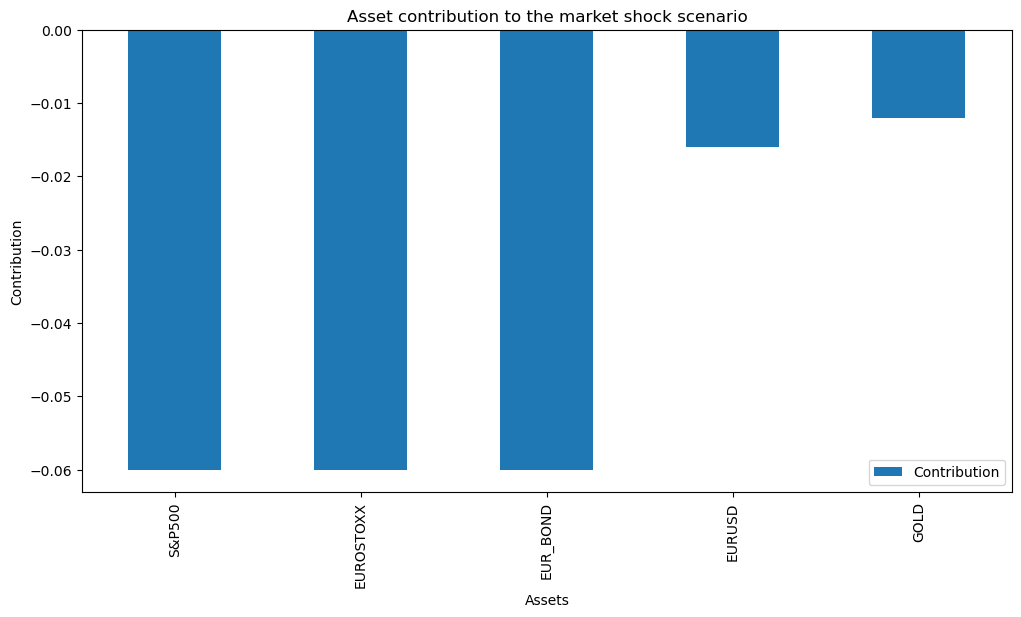

In [ ]:
# market shock table
stress_table = pd.DataFrame({
    "Weight": weights,
    "Shock": market_shock,
    "Contribution": weights * market_shock
})

print(stress_table)
stress_table[["Contribution"]].plot(kind="bar", figsize=(12, 6))
plt.title("Asset contribution to the market shock scenario")
plt.xlabel("Assets")
plt.ylabel("Contribution")
plt.legend(loc="best")
plt.show()


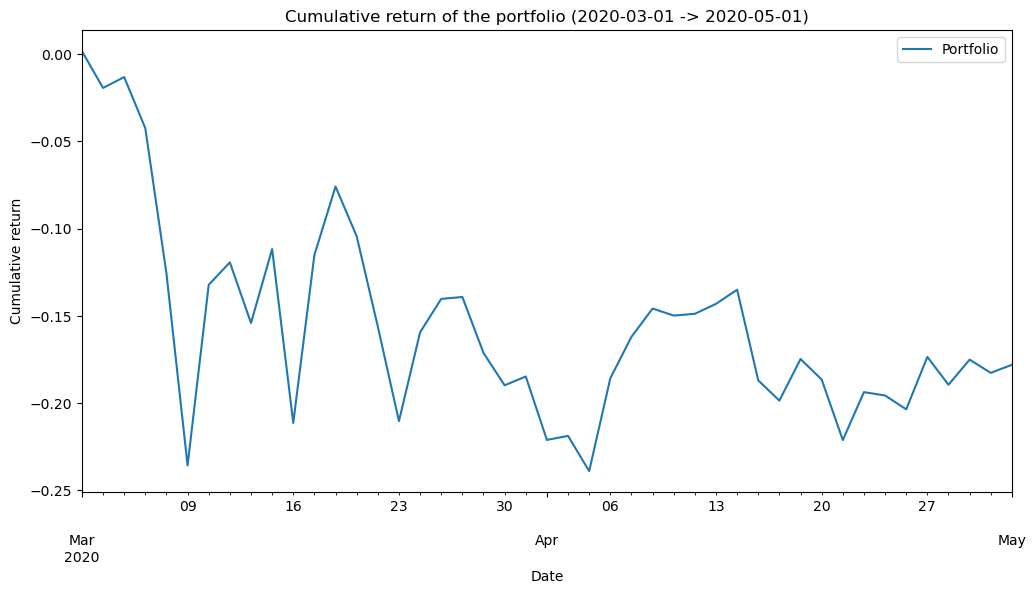

In [ ]:
# plot the cumulative return of the portfolio over the selected period
portfolio_window = portfolio.loc[START:END]
cumulative_portfolio = np.exp(portfolio_window.cumsum()) - 1

cumulative_portfolio.plot(figsize=(12, 6))
plt.title(f"Cumulative return of the portfolio ({START} -> {END})")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.show()


In [ ]:

historical_var_95 = np.percentile(market_window, (1 - CONFIDENCE_1) * 100)
historical_var_99 = np.percentile(market_window, (1 - CONFIDENCE_2) * 100)
historical_es_95 = market_window[market_window <= historical_var_95].mean()

print("Historical VaR 95% over the selected window:", f"{historical_var_95:.2%}")
print("Historical VaR 99% over the selected window:", f"{historical_var_99:.2%}")
print("Historical ES 95% over the selected window:", f"{historical_es_95:.2%}")


Historical VaR 95% over the selected window: -8.61%
Historical VaR 99% over the selected window: -12.77%


TypeError: unsupported format string passed to Series.__format__

In [ ]:
# historical max drawdown over the selected window
window_path = np.exp(market_window.cumsum())
window_drawdown = window_path / window_path.cummax() - 1
max_drawdown = -window_drawdown.min()
print("Historical max drawdown:", f"{max_drawdown:.2%}")

Historical max drawdown: 24.03%


In [ ]:
# worst asset
worst_asset = (weights * market_shock).idxmin()
worst_contribution = (weights * market_shock).min()
print("Worst asset:", worst_asset)
print("Worst contribution:", f"{worst_contribution:.2%}")

# worst historical day in the selected window
worst_day = market_window.idxmin()
worst_return = market_window.min()

print("Worst day:", worst_day.date())
print("Worst return:", f"{worst_return:.2%}")

Worst asset: S&P500
Worst contribution: -6.00%
Worst day: 2020-03-09
Worst return: -13.45%
